# CelComen HM11  Undirected Signed Coupling Network

**Scope:** This notebook is only for the **HM11 section**. At this stage, we are trying this analysis to inspect the strongest signed gene-to-gene couplings learned by CelComen.

The network is **undirected** because the coupling matrix is symmetric. Edge colour shows whether a coupling is supportive or antagonistic, and edge width shows its magnitude. This is an exploratory coupling analysis, **not a causal-direction claim**.


## 1. Load the HM11 files

Required files:
- `W_HM11.npy`
- `sec_meta_HM11.json`

Optional file for node themes:
- `HM11_drivers_per_CC.csv`

Place them in the notebook folder or under `handoff_to_eva/data` and `handoff_to_eva/drivers`.


In [ ]:
import os, json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

SECTION = "HM11"


def first_existing(*paths):
    for path in paths:
        if path and os.path.exists(path):
            return os.path.abspath(path)
    return None

G2G_FILE = first_existing(
    f"W_{SECTION}.npy",
    f"handoff_to_eva/data/W_{SECTION}.npy",
    f"/content/handoff_to_eva/data/W_{SECTION}.npy",
)
META_FILE = first_existing(
    f"sec_meta_{SECTION}.json",
    f"handoff_to_eva/data/sec_meta_{SECTION}.json",
    f"/content/handoff_to_eva/data/sec_meta_{SECTION}.json",
)
DRIVER_FILE = first_existing(
    f"{SECTION}_drivers_per_CC.csv",
    f"handoff_to_eva/drivers/{SECTION}_drivers_per_CC.csv",
    f"/content/handoff_to_eva/drivers/{SECTION}_drivers_per_CC.csv",
)

if not G2G_FILE or not META_FILE:
    raise FileNotFoundError(
        "HM11 input files were not found. Add W_HM11.npy and "
        "sec_meta_HM11.json to the notebook folder or handoff_to_eva/data."
    )

print(f"Section: {SECTION}")
print(f"Coupling matrix: {os.path.basename(G2G_FILE)}")
print(f"Metadata: {os.path.basename(META_FILE)}")
print(f"Driver themes: {os.path.basename(DRIVER_FILE) if DRIVER_FILE else 'not available'}")


## 2. Load and validate the HM11 coupling matrix


In [3]:
meta = json.load(open(META_FILE, encoding="utf-8"))
genes = [str(g).upper() for g in meta["gene_names"]]
W = np.load(G2G_FILE)

if W.ndim != 2 or W.shape[0] != W.shape[1]:
    raise ValueError(f"W must be square; received {W.shape}")
if W.shape[0] != len(genes):
    raise ValueError(
        f"Gene count ({len(genes)}) does not match W ({W.shape[0]} × {W.shape[1]})."
    )

print(f"Genes: {len(genes)}")
print(f"W shape: {W.shape}")
print(f"Symmetric: {np.allclose(W, W.T)}")


Genes: 117
W shape: (117, 117)
Symmetric: True


## 3. Assign optional HM11 node themes

When the driver table contains `gene` and `theme` columns, those themes are used to colour the nodes. Genes without a theme remain neutral.


In [4]:
niche = {}
if DRIVER_FILE:
    driver_df = pd.read_csv(DRIVER_FILE)
    if {"gene", "theme"}.issubset(driver_df.columns):
        niche = {
            str(gene).upper(): theme
            for gene, theme in zip(driver_df["gene"], driver_df["theme"])
        }

print(f"Genes with theme information: {len(niche)}")


Genes with theme information: 186


## 4. Select the strongest undirected HM11 couplings

`PANEL_MODE = "raw"` uses the learned coupling matrix directly. The strongest 60 unique gene pairs are retained.


In [5]:
PANEL_MODE = "raw"
TOP = 60


def perturbation_panel(matrix, alpha_frac=0.8):
    n = matrix.shape[0]
    spectral_radius = np.max(np.abs(np.linalg.eigvals(matrix)))
    scaled = alpha_frac / (spectral_radius + 1e-9)
    return np.linalg.inv(np.eye(n) - scaled * matrix) - np.eye(n)

M = perturbation_panel(W) if PANEL_MODE == "propagate" else W

pairs = [
    (abs(M[i, j]), i, j, float(M[i, j]))
    for i in range(len(genes))
    for j in range(i + 1, len(genes))
]
pairs.sort(reverse=True)
edges = [(genes[i], genes[j], weight) for _, i, j, weight in pairs[:TOP]]

n_supportive = sum(weight > 0 for _, _, weight in edges)
n_antagonistic = len(edges) - n_supportive

edge_df = pd.DataFrame(
    [(a, b, weight, "+" if weight > 0 else "−") for a, b, weight in edges],
    columns=["gene_a", "gene_b", "coupling", "sign"],
)

OUT = f"celcomen_undirected_network_{SECTION}"
edge_df.to_csv(f"{OUT}_edges.csv", index=False)

print(
    f"Panel: {PANEL_MODE} | {len(edges)} strongest undirected edges "
    f"({n_supportive} supportive, {n_antagonistic} antagonistic)"
)
print(
    f"Weight range: [{min(weight for _, _, weight in edges):+.3f}, "
    f"{max(weight for _, _, weight in edges):+.3f}]"
)
print(f"Saved: {OUT}_edges.csv")


Panel: raw | 60 strongest undirected edges (29 supportive, 31 antagonistic)
Weight range: [-1.000, +0.999]
Saved: celcomen_undirected_network_HM11_edges.csv


## 5. Plot the HM11 signed coupling network

- **Supportive coupling (+):** coral line
- **Antagonistic coupling (−):** teal line
- **Line width:** absolute coupling strength
- **Node colour:** available HM11 theme


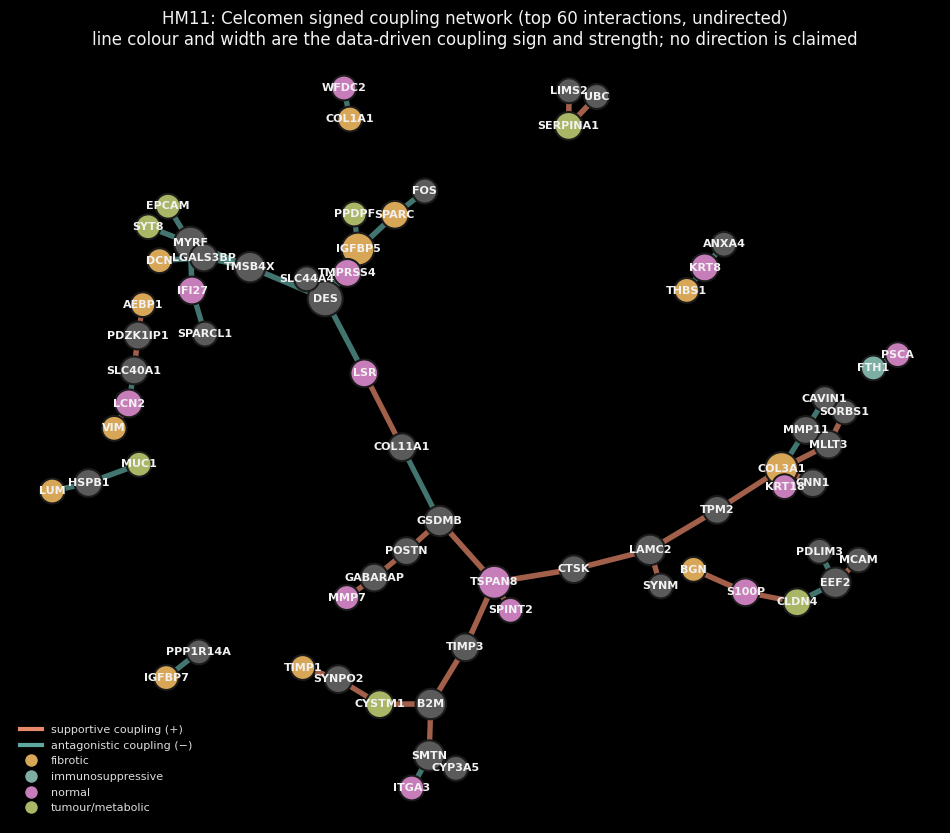

Saved: celcomen_undirected_network_HM11.png (68 genes shown)


In [6]:
G = nx.Graph()
for gene_a, gene_b, weight in edges:
    G.add_edge(gene_a, gene_b, weight=weight)

nodes = list(G.nodes())
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(12, 10))
pos = nx.spring_layout(
    G,
    seed=3,
    k=3.4 / np.sqrt(max(len(nodes), 1)),
    iterations=150,
)

themes = sorted({niche.get(gene) for gene in nodes if niche.get(gene)})
palette = {
    theme: colour
    for theme, colour in zip(
        themes,
        ["#d8a657", "#7daea3", "#c77dba", "#a9b665", "#bd6f3e"],
    )
}

degree = dict(G.degree())
node_sizes = [240 + 80 * degree.get(gene, 0) for gene in nodes]

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=nodes,
    node_color=[palette.get(niche.get(gene), "#5a5a5a") for gene in nodes],
    node_size=node_sizes,
    edgecolors="#1b1b1b",
    linewidths=1.5,
    ax=ax,
)
nx.draw_networkx_labels(
    G,
    pos,
    font_size=8,
    font_color="#f2f2f2",
    font_weight="bold",
    ax=ax,
)

SUPPORTIVE = "#e8896b"
ANTAGONISTIC = "#5fa8a0"
for gene_a, gene_b, weight in edges:
    ax.plot(
        [pos[gene_a][0], pos[gene_b][0]],
        [pos[gene_a][1], pos[gene_b][1]],
        color=SUPPORTIVE if weight > 0 else ANTAGONISTIC,
        lw=0.8 + 3.2 * abs(weight),
        alpha=0.7,
        zorder=0,
    )

legend = [
    Line2D([0], [0], color=SUPPORTIVE, lw=3, label="supportive coupling (+)"),
    Line2D([0], [0], color=ANTAGONISTIC, lw=3, label="antagonistic coupling (−)"),
]
legend += [
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=palette[theme],
        markersize=10,
        label=theme,
    )
    for theme in themes
]
ax.legend(
    handles=legend,
    loc="lower left",
    fontsize=8,
    frameon=False,
    labelcolor="#ddd",
)

ax.set_title(
    f"{SECTION}: CelComen signed coupling network "
    f"(top {len(edges)} interactions, undirected)
"
    "Line colour and width show coupling sign and strength; no direction is claimed",
    color="#f2f2f2",
    fontsize=12,
)
ax.axis("off")
fig.savefig(f"{OUT}.png", facecolor="#0d0d0d", bbox_inches="tight", dpi=160)
plt.show()
print(f"Saved: {OUT}.png ({len(nodes)} genes shown)")


## Interpretation boundary

This HM11 notebook visualizes the **strongest learned couplings** and their signs. Because `W` is symmetric, the edges do not establish which gene drives another. Therefore, this result should be presented as an **undirected association/coupling network**, not as causal direction. Directional causality must be evaluated separately with appropriate causal-discovery methods and assumptions.
